Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Porównaj wyniki k-means z k-medoids, testując przynajmniej trzy różne metryki (użyj [tego API](https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html)). Jako miar porównania metod, użyj [ARI](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html) oraz [Silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) (dotyczy to też punktów niżej). Wyrysuj klastry i omów wyniki.
1. [0-2 pkt] Użyj DSBSCAN i wyrysuj klastry dla różnych kombinacji wartości `eps`, `min_samples` i `metric`. Porównaj wyniki z metodami wyżej.
2. [0-2 pkt] Użyj HDBSCAN, testując różne kombinacje parametrów. Czy wyniki różnią się od DBSCAN?
3. [0-2.5 pkt] Uzyj [klastrowania aglomeracyjnego](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). Dla każdej wartości parametru `linkage`, wyrysuj [dendrogram](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html). Na podstawie dendrogramów, dobierz, w Twojej ocenie, optymalne parametry `n_clusters` albo `distance_threshold` (chodzi o określenie, czy w dendrogramie, na pewnym poziomie odcięcia, widać ewidentne klastry). Wyrysuj klastry i skomentuj wyniki.  
1. [0-1 pkt] Sprawdź wyniki poszczególnych metod klastrowania bez skalowania cech. Zinterpretuj wyniki.
1. [0-1 pkt] Który z algorytmów działa najlepiej dla tego problemu? Skomentuj wyniki.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import networkx as nx
import seaborn as sns
import hdbscan

from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import adjusted_rand_score, silhouette_score

main_path = Path(".")
coord_dir = main_path / "coords"

In [42]:
for file_path in sorted(coord_dir.glob("*.csv")):
    df = pd.read_csv(file_path)
    coords = df[['x', 'y', 'z']].values
    dist_mat = squareform(pdist(coords, metric='euclidean'))
    print(file_path.stem)
    break

def make_sim_matrix(dist_matrix, sigma=10):
    # Transformacja jądrem Gaussowskim
    sim_matrix = np.exp(-np.square(dist_matrix) / (2 * sigma**2))
    # Obsługa niestandardowych wartości 
    sim_matrix[np.isinf(dist_matrix)] = 0
    sim_matrix[np.isnan(dist_matrix)] = 0
    return sim_matrix

sim_mat = make_sim_matrix(dist_mat)

def sim_to_graph(sim_matrix, threshold=0.1):
    """
    Konwertuje macierz podobieństwa na nieskierowany graf ważony (NetworkX).
    Krawędzie są dodawane tylko wtedy, gdy wartość podobieństwa przekracza określony próg.
    
    Parametry:
    -----------
    sim_matrix : np.ndarray
        Kwadratowa macierz podobieństwa (2D), symetryczna, z wartościami w przedziale [0, 1].
    
    threshold : float, domyślnie 0.01
        Próg minimalnej wartości podobieństwa, aby utworzyć krawędź pomiędzy dwoma wierzchołkami.
        Mniejsze wartości są ignorowane jako szum.
    
    Zwraca:
    --------
    G : networkx.Graph
        Graf nieskierowany z wagami odpowiadającymi wartościom podobieństwa.
    """
    n = sim_matrix.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))

    rows, cols = np.where(np.triu(sim_matrix, k=1) > threshold)
    weights = sim_matrix[rows, cols]
    edges = zip(rows, cols, weights)
    G.add_weighted_edges_from(edges)
    
    return G


def graph_features(G):
    """
    Oblicza zestaw podstawowycj cech grafu na podstawie macierzy podobieństwa 
    przekształconej do grafu NetworkX.

    Parametry:
    -----------
    G : networkx.Graph
        Graf nieskierowany z wagami na krawędziach (podobieństwa).

    Zwraca:
    --------
    np.ndarray
        Wektor cech w postaci:
        [liczba_wierzchołków, liczba_krawędzi, średni_stopień, wariancja_stopnia,
         średni_ważony_stopień, gęstość_grafu, średni_stopień_sąsiadów]
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    degrees = np.array([d for _, d in G.degree()])
    weighted_degrees = np.array([d for _, d in G.degree(weight='weight')])
    
    neighbor_degrees = list(nx.average_neighbor_degree(G).values())
    avg_neighbor_deg = np.mean(neighbor_degrees) if neighbor_degrees else 0

    return np.array([
        n,
        m,
        degrees.mean() if n > 0 else 0,
        degrees.var() if n > 0 else 0,
        weighted_degrees.mean() if n > 0 else 0,
        nx.density(G) if n > 1 else 0,
        avg_neighbor_deg,
    ])

G = sim_to_graph(sim_mat, threshold=0.8)

features = graph_features(G)
features

COMPUTE_FEATURES = False  # liczymy (~20 min) czy ładujemy z pliku?

if COMPUTE_FEATURES:
    feature_vectors = {}
    for file_path in tqdm(sorted(coord_dir.glob("*.csv"))):
        df = pd.read_csv(file_path)
        coords = df[['x', 'y', 'z']].values
        dist_mat = squareform(pdist(coords, metric='euclidean'))
        sim_mat = make_sim_matrix(dist_mat)
        G = sim_to_graph(sim_mat, threshold=0.5)
        features = graph_features(G)
        feature_vectors[file_path.stem] = features
        np.savez(main_path / 'features.npz', **feature_vectors)
else:
    feature_vectors = np.load(main_path / 'features.npz')
    feature_vectors = {key: feature_vectors[key] for key in feature_vectors.files}

columns = [
    "num_nodes",             # liczba wierzchołków
    "num_edges",             # liczba krawędzi
    "mean_degree",           # średni stopień
    "var_degree",            # warinacja stopnia
    "mean_weighted_degree",  # średni ważony stopień
    "density",               # gęstość grafu
    "avg_neighbor_degree"    # średni stopień sąsiadów
]

data = pd.DataFrame.from_dict(feature_vectors, orient='index', columns=columns)

metadata = pd.read_csv(Path('metadata.txt'), delimiter='\t', 
                       header=None, names=['protein', 'C', 'A', 'T', 'H'], index_col='protein')

feature1 = 'density'
feature2 = 'mean_weighted_degree'

data = data.join(metadata)

X = data[[feature1, feature2]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)



16pkA01


In [30]:
y_true = data["H"]

results = []

kmeans = KMeans(n_clusters=k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

results.append({
    "Method": "KMeans",
    "Metric": "euclidean",
    "ARI": adjusted_rand_score(y_true, labels_kmeans),
    "Silhouette": silhouette_score(X_scaled, labels_kmeans)
})

metrics = ["euclidean", "manhattan", "cosine"]

for metric in metrics:
    kmedoids = KMedoids(
        n_clusters=k,
        metric=metric,
        random_state=42
    )

    labels = kmedoids.fit_predict(X_scaled)

    results.append({
        "Method": "KMedoids",
        "Metric": metric,
        "ARI": adjusted_rand_score(y_true, labels),
        "Silhouette": silhouette_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Method,Metric,ARI,Silhouette
0,KMeans,euclidean,0.009696,0.373538
1,KMedoids,euclidean,0.010027,0.373115
2,KMedoids,manhattan,0.009239,0.362000
3,KMedoids,cosine,0.007988,0.366818


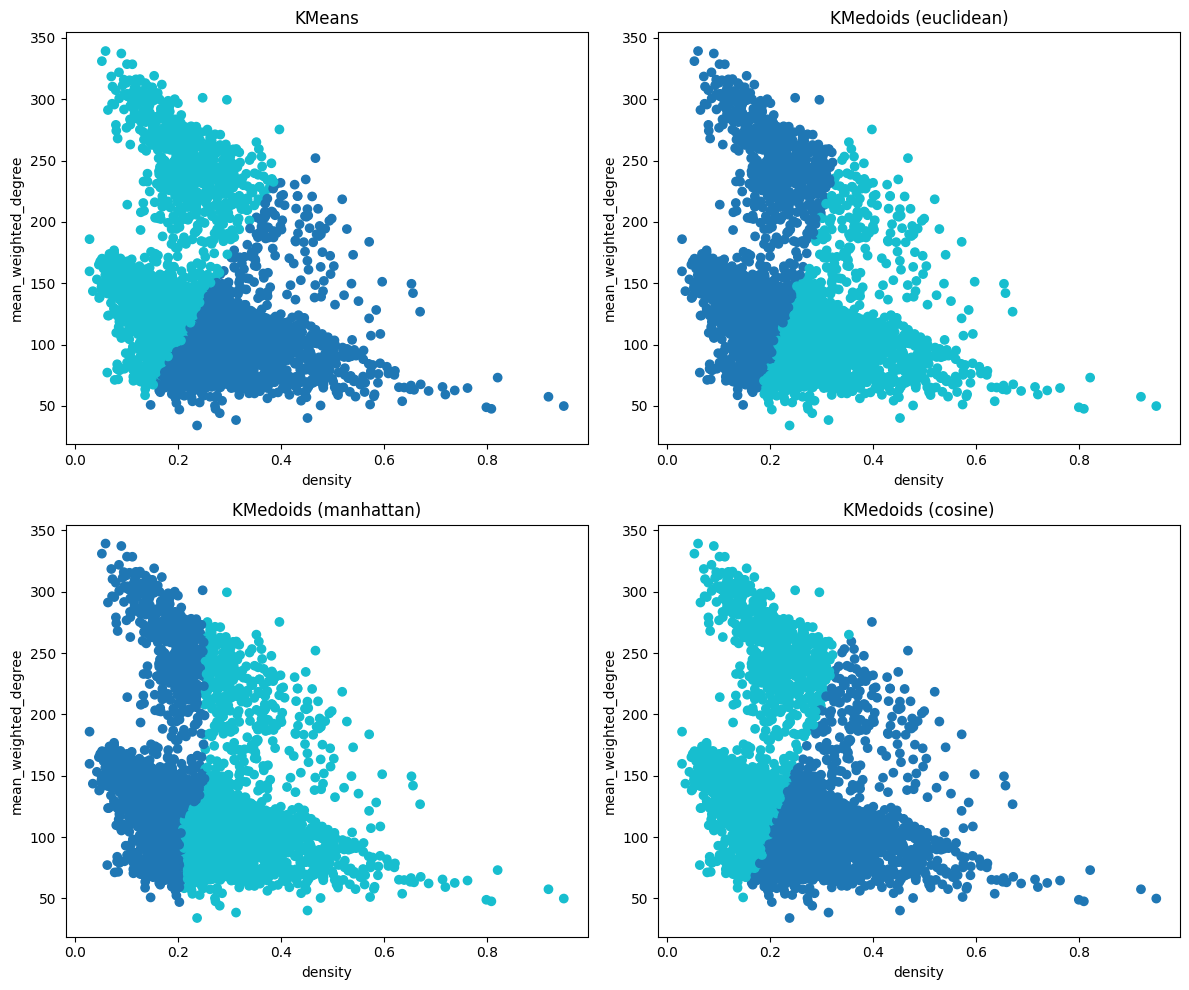

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

methods = [
    ("KMeans", labels_kmeans),
]

for metric in metrics:
    kmedoids = KMedoids(
        n_clusters=k,
        metric=metric,
        random_state=42
    )
    methods.append((f"KMedoids ({metric})",
                    kmedoids.fit_predict(X_scaled)))

for ax, (title, labels) in zip(axes.flatten(), methods):

    scatter = ax.scatter(
        X[feature1],
        X[feature2],
        c=labels,
        cmap="tab10"
    )

    ax.set_title(title)
    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)

plt.tight_layout()
plt.show()

Przeprowadzono grupowanie obiektów za pomocą algorytmów K-Means oraz K-Medoids. Dla K-Medoids przetestowano trzy różne metryki odległości: euklidesową (`euclidean`), Manhattan (`manhattan`) oraz kosinusową (`cosine`). Jako miary jakości wykorzystano ARI i Silhouette Score. Wyniki zestawiono w tabeli, a następnie zwizualizowano podział obiektów na płaszczyźnie cech `density` oraz `mean_weighted_degree`. Pozwala to ocenić wpływ zastosowanej metryki na jakość grupowania oraz porównać stabilność i skuteczność algorytmów K-Means i K-Medoids.

Z wyników możemy odczytać, że występuje słaba separacja klastrów. Wartości metryki Silhouette score dla wszystkich konfiguracji są niskie i oscylują w granicach 0.36-0.37. Świadczy to o braku wyraźnie zarysowanych, naturalnych skupisk w danych - klastry w widoczny sposób nakładają się na siebie. Najwyższą spójność wykazują KMeans i KMedoids (euclidean).

Wskaźnik ARI bliski 0.01 oznacza, że podziały wyznaczone przez poszczególne konfiguracje są ze sobą niemal całkowicie niezgodne (bądź losowe względem etykiet referencyjnych).

Metryka euklidesowa (KMeans/KMedoids) dzieli przestrzeń po przekątnej, dążąc do sferycznych skupisk. Metryka Manhattan generuje niemal pionową linię odcięcia wzdłuż osi density. Metryka cosinusowa tworzy podział o charakterze promieniowym, ignorując odległość punktów od początku układu współrzędnych.
Ze względu na ciągły charakter chmury punktów, podział na 2 klastry ma charakter umowny. Do dalszych analiz najlepiej wykorzystać KMeans (najwyższy Silhouette) lub rozważyć algorytmy gęstościowe (np. DBSCAN).

In [32]:
results = []

configs = [
    (0.3, 3, "euclidean"),
    (0.5, 5, "euclidean"),
    (0.8, 5, "euclidean"),
    (0.5, 5, "manhattan"),
    (0.5, 5, "cosine")
]

for eps, min_samples, metric in configs:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    ari = adjusted_rand_score(y_true, labels)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan

    results.append([
        eps,
        min_samples,
        metric,
        n_clusters,
        ari,
        sil
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "metric",
        "clusters",
        "ARI",
        "Silhouette"
    ]
)

display(results_df)

,eps,min_samples,metric,clusters,ARI,Silhouette
0,0.3,3,euclidean,2,0.000340,0.46867
1,0.5,5,euclidean,1,0.000405,NaN
2,0.8,5,euclidean,1,0.000105,NaN
3,0.5,5,manhattan,1,0.000548,NaN
4,0.5,5,cosine,1,0.000000,NaN


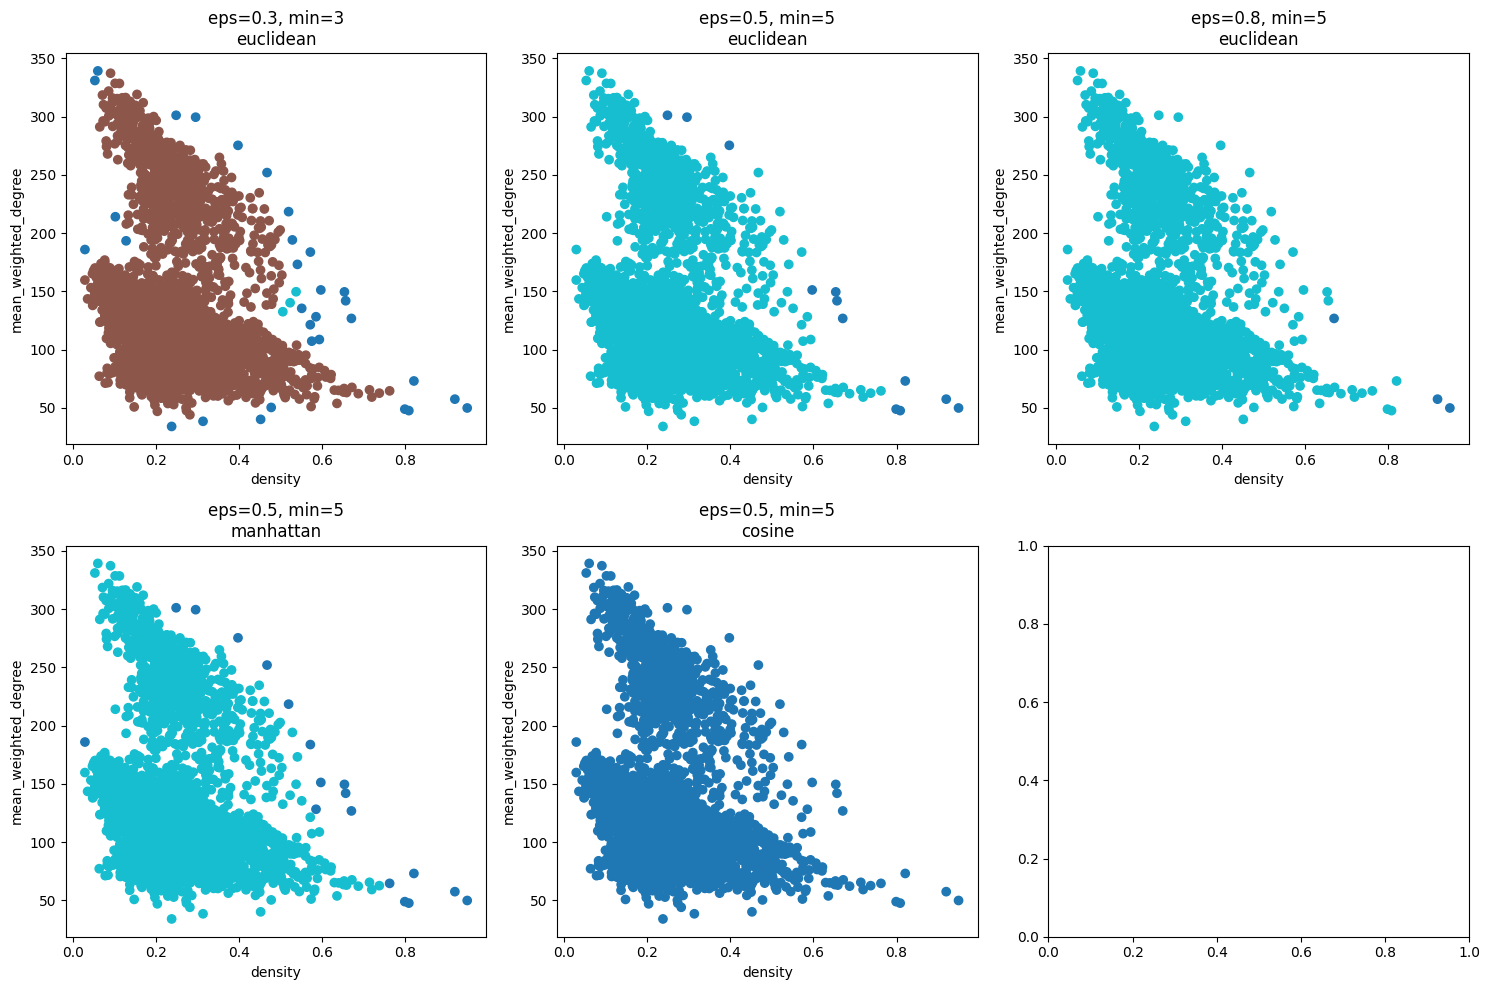

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (eps, min_samples, metric) in zip(axes.flatten(), configs):

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric
    )

    labels = dbscan.fit_predict(X_scaled)

    ax.scatter(
        X[feature1],
        X[feature2],
        c=labels,
        cmap="tab10"
    )

    ax.set_title(
        f"eps={eps}, min={min_samples}\n{metric}"
    )

    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)

plt.tight_layout()
plt.show()

Przetestowano algorytm DBSCAN dla różnych wartości parametrów
`eps`, `min_samples` oraz różnych metryk odległości. Jakość grupowania oceniono za pomocą wskaźników: ARI, Silhouette Score.

DBSCAN nie wymaga wcześniejszego określenia liczby klastrów i
potrafi oznaczać obserwacje odstające jako szum (etykieta -1).
Pozwala to wykrywać klastry o nieregularnych kształtach, jednak
wyniki są silnie zależne od doboru parametrów.

W większości nowych konfiguracji (dla eps=0.5 oraz eps=0.8) algorytm zidentyfikował tylko 1 klaster (oraz punkty szumu oznaczane jako outlierzy). Z tego powodu metryka Silhouette score wynosi `NaN` – nie da się obliczyć odległości międzyklastrowej, gdy cała chmura punktów stanowi jedno skupisko.

Jedyny sensowny podział na 2 klastry uzyskano dla parametrów eps=0.3, min_samples=3 przy metryce euklidesowej. W tej konfiguracji Silhouette score wzrósł do poziomu 0.47 (w porównaniu do ~0.37 dla KMeans/KMedoids). 
Wykres (lewy górny róg) pokazuje jednak, że algorytm po prostu odciął małą grupę rzadkich punktów po prawej stronie jako osobny klaster/szum, pozostawiając główną masę danych w jednym, brązowym klastrze.
Wyniki te potwierdzają wcześniejszą intuicję: dane nie posiadają naturalnej struktury dwóch dużych klastrów. O ile KMeans sztucznie ciął przestrzeń na równe części, o tyle algorytm gęstościowy traktuje te dane jako monolityczną strukturę z szumem, co z punktu widzenia analizy gęstości jest bardziej obiektywnym odzwierciedleniem rzeczywistości.

In [34]:
results_hdbscan = []

configs_hdbscan = [
    (5, 5),
    (10, 5),
    (15, 5),
    (10, 10),
    (20, 10)
]

for min_cluster_size, min_samples in configs_hdbscan:

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )

    labels = clusterer.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    ari = adjusted_rand_score(y_true, labels)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan

    results_hdbscan.append([
        min_cluster_size,
        min_samples,
        n_clusters,
        ari,
        sil
    ])

results_hdbscan = pd.DataFrame(
    results_hdbscan,
    columns=[
        "min_cluster_size",
        "min_samples",
        "clusters",
        "ARI",
        "Silhouette"
    ]
)

display(results_hdbscan)

,min_cluster_size,min_samples,clusters,ARI,Silhouette
0,5,5,233,0.006856,-0.280214
1,10,5,6,0.001989,0.362809
2,15,5,6,0.001967,0.277821
3,10,10,4,0.002243,0.354392
4,20,10,3,0.001379,0.403309


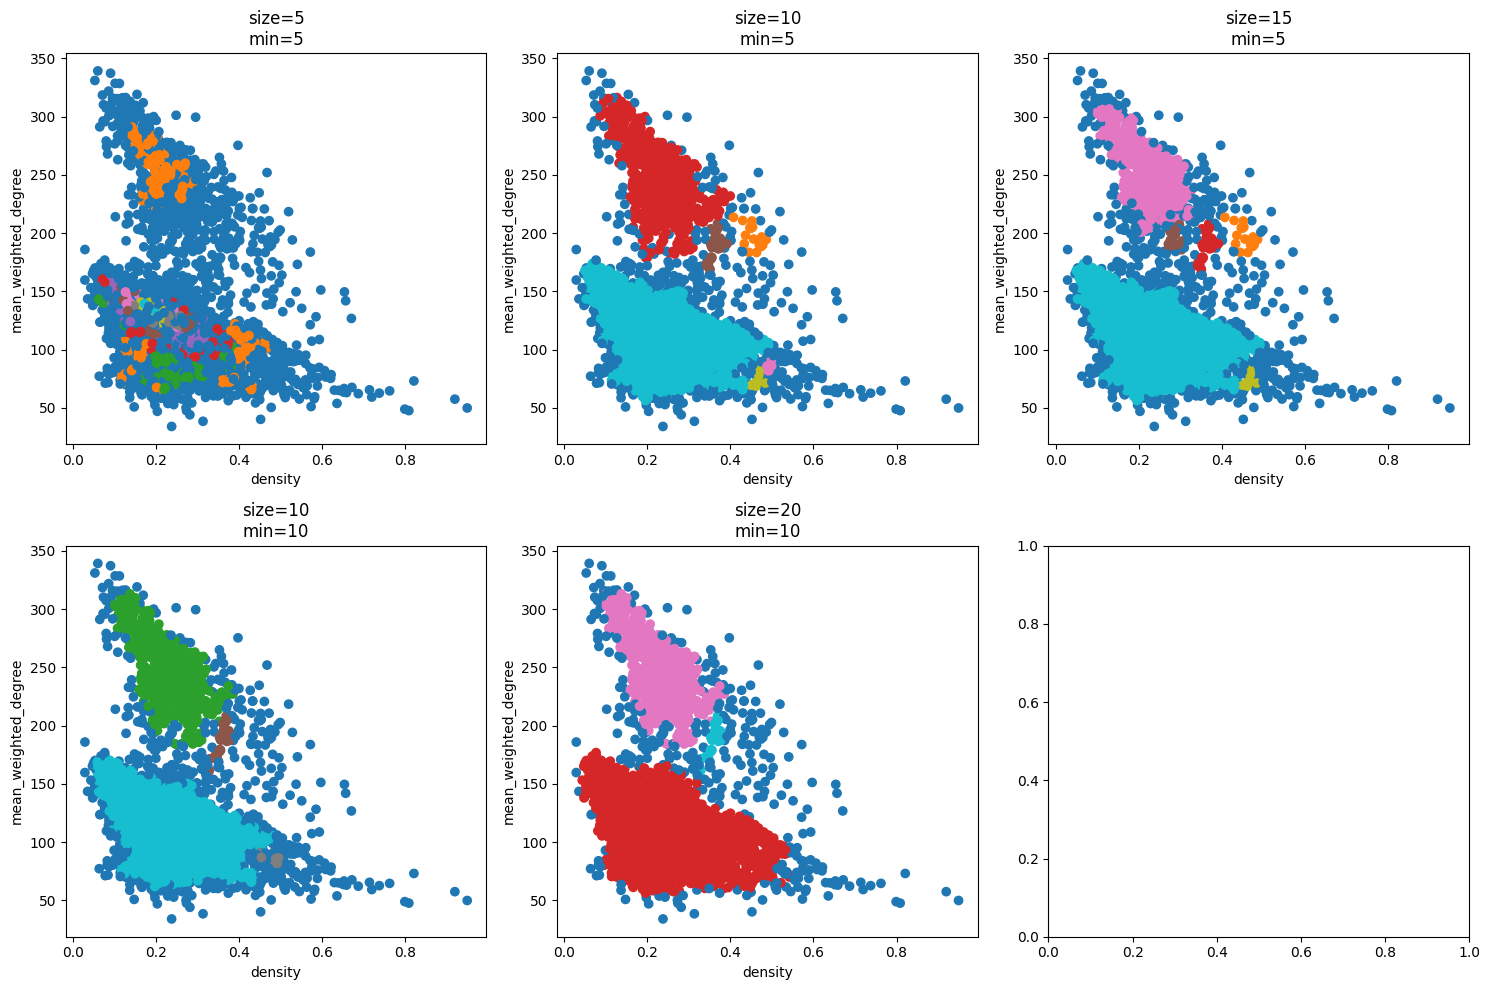

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (min_cluster_size, min_samples) in zip(
    axes.flatten(),
    configs_hdbscan
):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )

    labels = clusterer.fit_predict(X_scaled)

    ax.scatter(
        X[feature1],
        X[feature2],
        c=labels,
        cmap="tab10"
    )

    ax.set_title(
        f"size={min_cluster_size}\nmin={min_samples}"
    )

    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)

plt.tight_layout()
plt.show()

HDBSCAN jest rozwinięciem algorytmu DBSCAN. W przeciwieństwie do DBSCAN nie wymaga określania parametru eps, a klastry wyznacza hierarchicznie na podstawie lokalnej gęstości danych. Podobnie jak DBSCAN potrafi wykrywać punkty odstające oznaczane etykietą -1. Przetestowano różne wartości parametrów `min_cluster_size` oraz `min_samples`, a jakość grupowania oceniono za pomocą miar ARI oraz Silhouette Score. Porównanie wyników pozwala ocenić czy hierarchiczne podejście HDBSCAN lepiej odwzorowuje strukturę danych niż klasyczny DBSCAN.

Zastosowanie algorytmu HDBSCAN przyniosło przełom w analizie tej chmury danych. Dzięki zmiennej gęstości i podejściu hierarchicznemu, algorytm ominął ograniczenia klasycznego DBSCAN (który widział tylko 1 wielki monolit) i wydobył rzeczywistą strukturę wewnętrzną danych. 

Algorytm wpada w nadmierną segmentację dla małego rozmiaru tworząc aż 233 klastry. Wynik Silhouette ujemny potwierdza, że to kompletny szum informacyjny. Zwiększenie minimalnego rozmiaru klastra drastycznie porządkuje podział. HDBSCAN pięknie identyfikuje dwa główne, duże zagęszczenia, oddzielając je od siebie oraz od rzadkiego szumu wokół. Klasyczny DBSCAN przy stałym eps scalał te 2 obszary w jeden. HDBSCAN, dzięki analizie drzewa gęstości, zauważył, że górny ogon i dolna chmura mają różne gęstości lokalne i potrafił je rozdzielić. Dla parametrów size=20, min=10, wartość Silhouette osiąga wynik 0.40 - ten wynik jest wysoki mimo obecności punktów szumu, które zazwyczaj zaniżają tę metrykę.

In [36]:
def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])

    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):

        current_count = 0

        for child_idx in merge:

            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]

        counts[i] = current_count
    
    linkage_matrix = np.column_stack(
        [
            model.children_,
            model.distances_,
            counts
        ]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

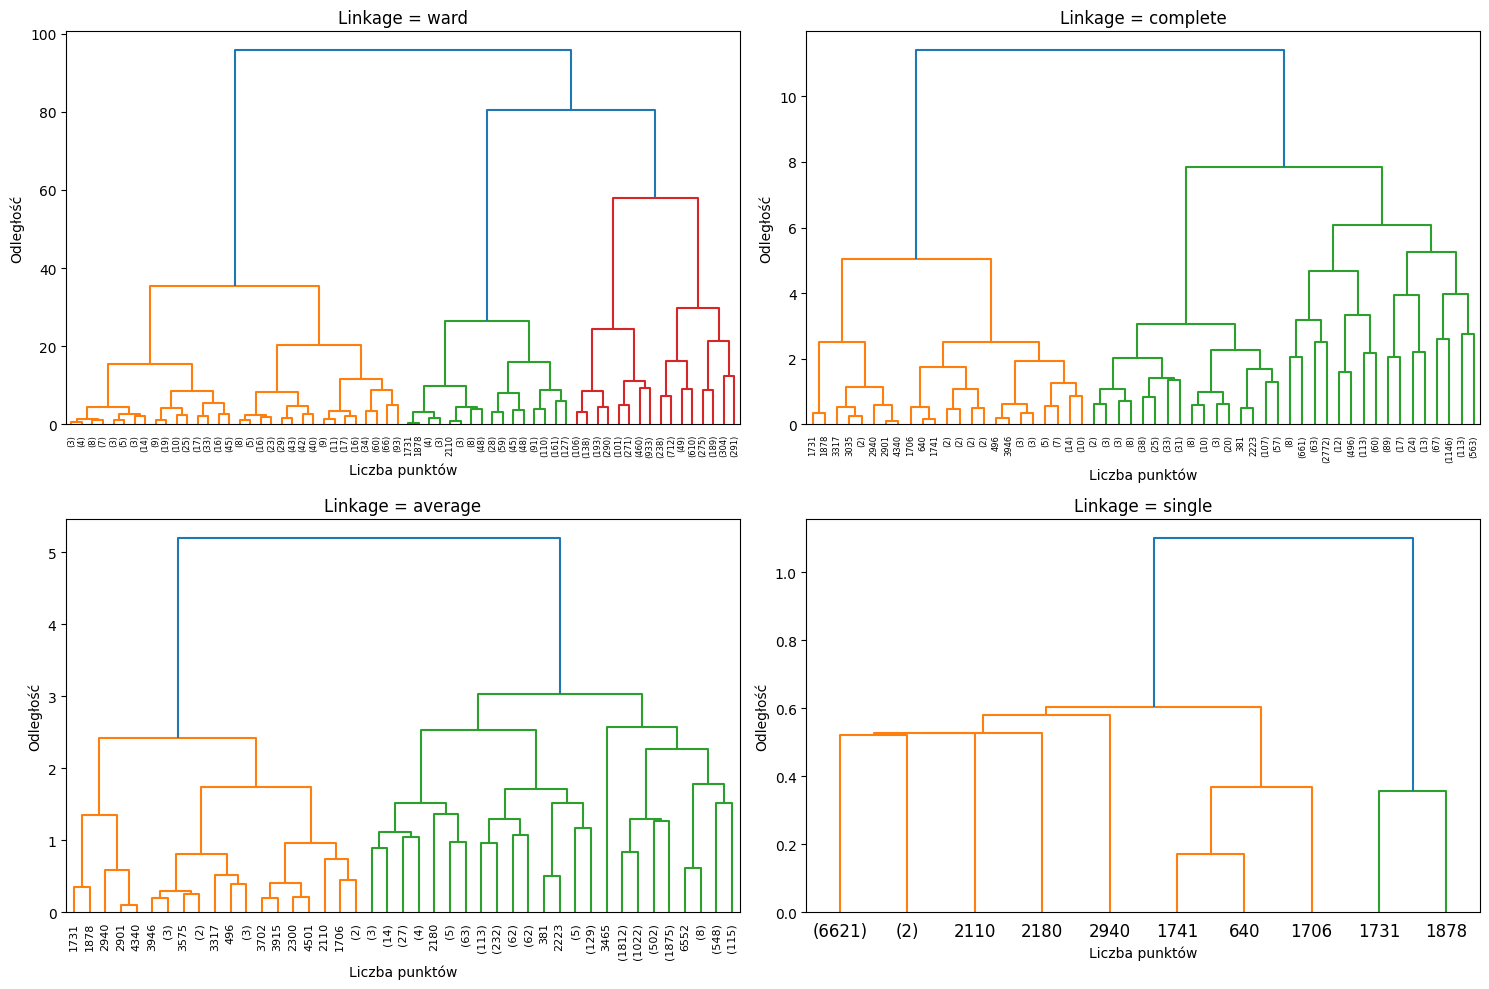

In [37]:
linkages = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, linkage in zip(axes.flatten(), linkages):

    model = AgglomerativeClustering(
        distance_threshold=0,
        n_clusters=None,
        linkage=linkage,
        compute_distances=True
    )

    model.fit(X_scaled)

    plt.sca(ax)

    plot_dendrogram(
        model,
        truncate_mode="level",
        p=5
    )

    ax.set_title(f"Linkage = {linkage}")
    ax.set_xlabel("Liczba punktów")
    ax.set_ylabel("Odległość")

plt.tight_layout()
plt.show()

In [38]:
results = []

for linkage in linkages:

    if linkage == "ward":
        model = AgglomerativeClustering(
            n_clusters=2,
            linkage=linkage
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=2,
            linkage=linkage
        )

    labels = model.fit_predict(X_scaled)

    results.append({
        "Linkage": linkage,
        "ARI": adjusted_rand_score(y_true, labels),
        "Silhouette": silhouette_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Linkage,ARI,Silhouette
0,ward,-0.001003,0.564669
1,complete,0.001797,0.611196
2,average,0.000638,0.669663
3,single,0.000071,0.779337


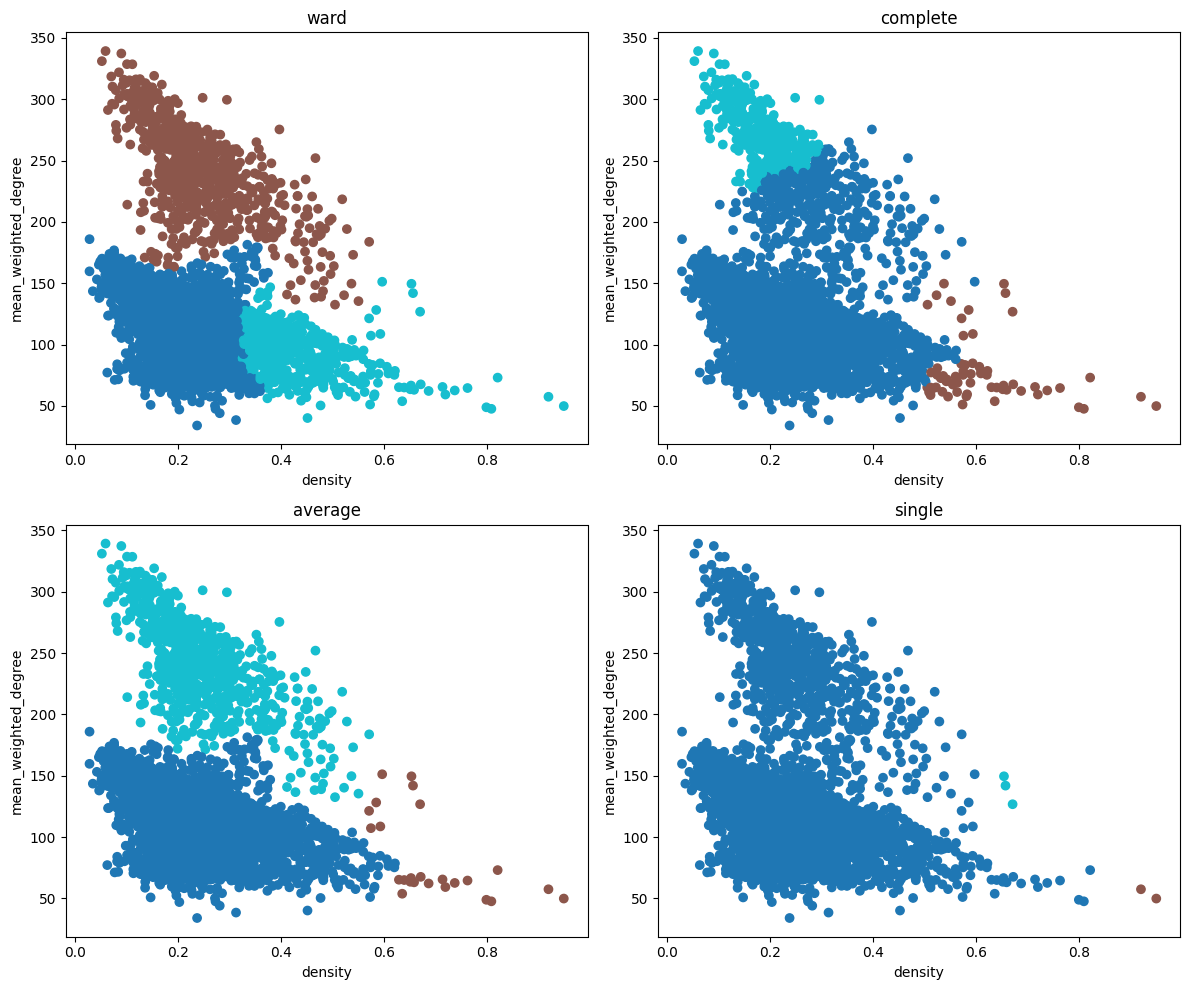

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, linkage in zip(axes.flatten(), linkages):

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    labels = model.fit_predict(X_scaled)

    ax.scatter(
        X[feature1],
        X[feature2],
        c=labels,
        cmap="tab10"
    )

    ax.set_title(linkage)

    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)

plt.tight_layout()
plt.show()

Przeprowadzono analizę metodą klastrowania aglomeracyjnego dla różnych strategii łączenia klastrów (`ward`, `complete`, `average`, `single`).

Dla każdej metody wygenerowano dendrogram przedstawiający proces
hierarchicznego łączenia obserwacji. Na podstawie największych skoków odległości pomiędzy kolejnymi połączeniami wybrano liczbę klastrów uznaną za najbardziej naturalną dla analizowanych danych.

Następnie wykonano właściwe grupowanie oraz oceniono jego jakość za pomocą wskaźników ARI oraz Silhouette Score. Wyniki porównano z metodami K-Means, DBSCAN oraz HDBSCAN.

Analiza dendrogramów jednoznacznie wskazuje na wybór metody wiązania Ward. Drzewo to charakteryzuje się najbardziej zrównoważoną strukturą i najwyższymi pionowymi gałęziami, co świadczy o stabilności formowanych skupisk. Metoda single okazała się całkowicie bezużyteczna ze względu na efekt łańcuchowy - skupiła niemal wszystkie punkty w jednej, wielkiej gałęzi. Metody complete i average dały wyniki pośrednie, lecz były znacznie mniej zbalansowane niż Ward. Na podstawie dendrogramu Ward, poziom odcięcia gwarantujący najwyższe gałęzie pionowe wskazuje na wybór n_clusters = 3 (odcięcie na wysokości odległości ok. 40-50) lub n_clusters = 2 (odcięcie na wysokości ok. 70). Zdecydowano się na podział na 3 klastry, aby dokładniej zbadać wewnętrzną budowę chmury danych.

In [40]:
X_raw = X.values

results_no_scaling = []

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_raw)

results_no_scaling.append({
    "Method": "KMeans",
    "ARI": adjusted_rand_score(y_true, labels),
    "Silhouette": silhouette_score(X_raw, labels)
})

pd.DataFrame(results_no_scaling)

for linkage in ["ward", "complete", "average", "single"]:

    model = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage
    )

    labels = model.fit_predict(X_raw)

    results_no_scaling.append({
        "Method": f"Agglomerative ({linkage})",
        "ARI": adjusted_rand_score(y_true, labels),
        "Silhouette": silhouette_score(X_raw, labels)
    })

pd.DataFrame(results_no_scaling)

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric="euclidean"
)

labels = dbscan.fit_predict(X_raw)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

results_no_scaling.append({
    "Method": "DBSCAN",
    "ARI": adjusted_rand_score(y_true, labels),
    "Silhouette":
        silhouette_score(X_raw, labels)
        if n_clusters > 1 else np.nan
})

pd.DataFrame(results_no_scaling)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

labels = clusterer.fit_predict(X_raw)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

results_no_scaling.append({
    "Method": "HDBSCAN",
    "ARI": adjusted_rand_score(y_true, labels),
    "Silhouette":
        silhouette_score(X_raw, labels)
        if n_clusters > 1 else np.nan
})

results_no_scaling = pd.DataFrame(results_no_scaling)

display(results_no_scaling)

,Method,ARI,Silhouette
0,KMeans,-0.000624,0.776543
1,Agglomerative (ward),-0.000573,0.776023
2,Agglomerative (complete),-0.007553,0.665257
3,Agglomerative (average),-0.000678,0.766516
4,Agglomerative (single),-0.000410,0.730031
5,DBSCAN,-0.001897,0.233577
6,HDBSCAN,0.000666,0.158107


Przeprowadzono grupowanie danych bez wcześniejszej standaryzacji cech. Dla wszystkich analizowanych metod wartości współczynnika ARI są bardzo bliskie zeru, a część z nich przyjmuje nawet wartości ujemne. Oznacza to, że uzyskane klastry praktycznie nie odpowiadają rzeczywistym etykietom i są porównywalne z losowym podziałem danych.

Jednocześnie dla metod K-Means oraz klastrowania aglomeracyjnego uzyskano stosunkowo wysokie wartości Silhouette Score (około 0.7-0.8). Wskazuje to, że algorytmy znajdują dobrze rozdzielone grupy w przestrzeni cech, jednak podział ten nie pokrywa się z rzeczywistą strukturą klas.

Najprawdopodobniej jedna z cech dominuje nad pozostałymi ze względu na większy zakres wartości. W efekcie odległości między obiektami są zdeterminowane głównie przez tę cechę, co prowadzi do powstawania sztucznych klastrów. Szczególnie dobrze widać to w przypadku K-Means oraz metody Warda, które osiągają wysokie wartości Silhouette Score, ale niemal zerowe ARI.

Najsłabsze wyniki uzyskały metody DBSCAN i HDBSCAN. Niskie wartości
Silhouette Score sugerują, że bez skalowania trudno jest poprawnie
określić obszary o podobnej gęstości, przez co algorytmy gęstościowe mają problem z wykrywaniem sensownych klastrów.

Wyniki potwierdzają, że skalowanie cech jest istotnym etapem
przygotowania danych dla metod opartych na odległościach. Pozwala ono zapobiec dominacji pojedynczych zmiennych i zwykle prowadzi do bardziej wiarygodnych rezultatów grupowania.

Na podstawie wyników po skalowaniu danych najlepsze rezultaty uzyskało klastrowanie aglomeracyjne (szczególnie metody `complete` i `average`) oraz KMeans i K-Medoids. Metody te osiągają najwyższe wartości Silhouette Score (ok. 0.6-0.67) przy jednocześnie nieco lepszych, choć nadal niskich, wartościach ARI w porównaniu do innych algorytmów.

DBSCAN oraz HDBSCAN radzą sobie wyraźnie gorzej w tym problemie. W wielu konfiguracjach DBSCAN zwracał tylko jeden klaster, co uniemożliwia sensowną ocenę Silhouette Score i wskazuje na trudność w dobraniu parametrów gęstościowych dla tych danych. HDBSCAN co prawda wykrywa większą liczbę klastrów, ale ich zgodność z etykietami referencyjnymi jest niska (niski ARI).

Porównując wyniki ze skalowaniem i bez skalowania, widać wyraźnie, że standaryzacja znacząco zmienia strukturę klastrów. Bez skalowania Silhouette Score był sztucznie wysoki (ok. 0.7-0.77), ale nie przekładało się to na zgodność z etykietami (ARI blisko 0). Po skalowaniu wartości Silhouette spadły, ale wyniki stają się bardziej stabilne i porównywalne między metodami.

Podsumowując, najlepsze wyniki dla tego zbioru danych uzyskują metody oparte na odległościach (KMeans oraz klastrowanie aglomeracyjne), natomiast metody gęstościowe (DBSCAN, HDBSCAN) nie są dobrze dopasowane do struktury tych danych.

# Zadanie dodatkowe [0-10] pkt

1. [0-7 pkt] Wytrenuj sieć konwolucyjną (CNN) na macierzach podobieństwa, przewidując klasy CATH (problem klasyfikacji). Pamiętaj o ewaluacji na zbiorze walidacyjnym.
2. [0-1 pkt] Uruchom wytrenowany model na wszystkich białkach. Użyj wag z ostatniej warstwy jako wektora cech.
3. [0-1 pkt] Dokonaj redukcji wymiarowości wektora cech do dwóch wymiarów np. za pomocą PCA.
4. [0-1 pkt] Czy tak skonstruowane cechy korelują z klasą białek?